In [5]:
!pip install tensorflow

In [6]:
import tensorflow

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
data=pd.read_csv("galaxyquasar.csv", sep=",")

In [9]:
u_g=data['u']-data['g']
g_r=data['g']-data['r']
r_i=data['r']-data['i']
i_z=data['i']-data['z']
z=data['z1']

In [10]:
y=np.zeros(len(data['class']))
y[data['class']=='QSO']=1

from sklearn.model_selection import train_test_split

X=np.array([u_g,g_r,r_i,i_z])
X=X.transpose()
X_train_full, X_test = train_test_split(X, test_size=0.2, random_state=42)
y_train_full, y_test = train_test_split(y, test_size=0.2, random_state=42)



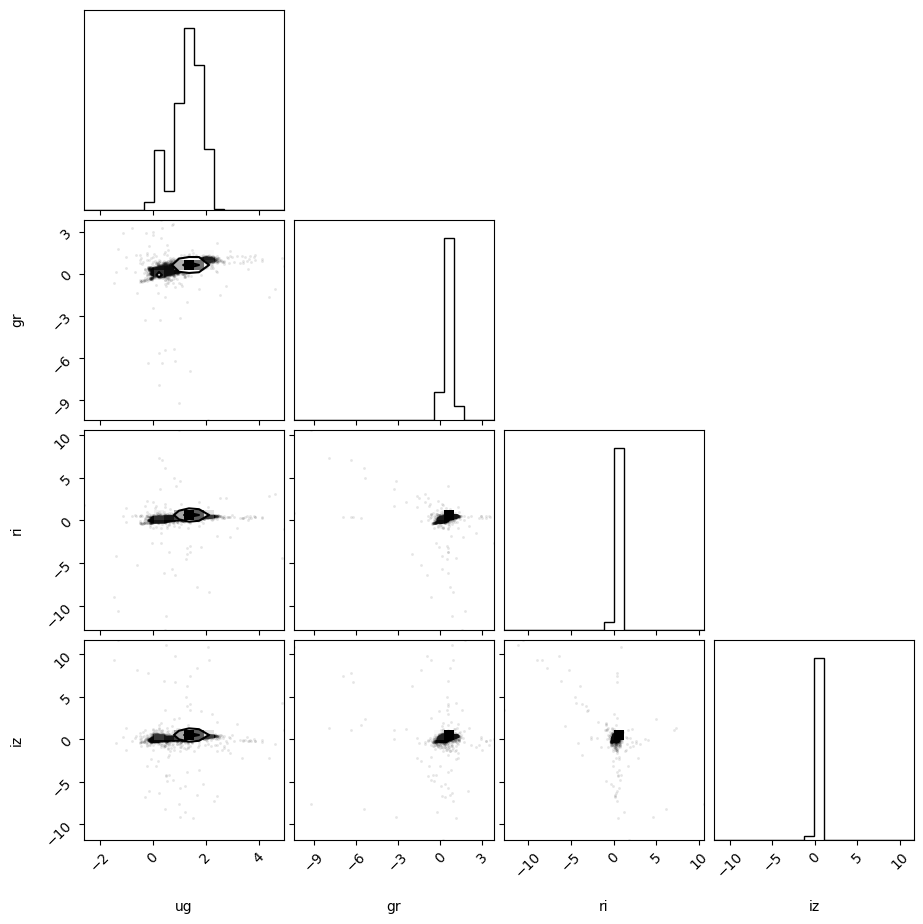

In [11]:
!pip install corner
import corner
corner.corner(X_train_full, labels=['ug', 'gr', 'ri', 'iz']);

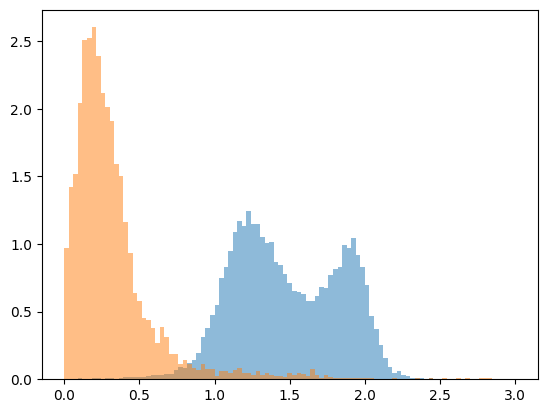

In [12]:
plt.hist(X_train_full[:,0][y_train_full==0], bins=np.linspace(0,3,100), density=True, alpha=0.5)
plt.hist(X_train_full[:,0][y_train_full==1], bins=np.linspace(0,3,100), density=True, alpha=0.5);

In [13]:
from tensorflow import keras

In [14]:
import tensorflow as tf

keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [15]:
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_train = X_train[:, :, np.newaxis]
X_valid = X_valid[:, :, np.newaxis]
X_test = X_test[:, :, np.newaxis]


In [16]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[4, 1]),
    keras.layers.Conv1D(filters=64, kernel_size=7, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=1),
    keras.layers.Conv1D(256, 3, activation='relu', padding='same'),
    keras.layers.Conv1D(256, 3, activation='relu', padding='same'),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [17]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 64)          │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 2, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 444,490 (1.70 MB)

 Trainable params: 444,490 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

None


In [18]:
model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.0001), metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.9358 - loss: 0.2785 - val_accuracy: 0.9830 - val_loss: 0.0779
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.9818 - loss: 0.0970 - val_accuracy: 0.9836 - val_loss: 0.0644
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.9833 - loss: 0.0813 - val_accuracy: 0.9834 - val_loss: 0.0589
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9841 - loss: 0.0717 - val_accuracy: 0.9846 - val_loss: 0.0570
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.9842 - loss: 0.0691 - val_accuracy: 0.9846 - val_loss: 0.0570
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.9848 - loss: 0.0658 - val_accuracy: 0.9860 - val_loss: 0.0530
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.9844 - loss: 0.0645 - val_accuracy: 0.9860 - val_loss: 0.0529
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 51s 28ms/step - accuracy: 0.9853 -

In [19]:
import sklearn
y_pred=np.argmax(model.predict(X_test), axis=-1)
print(sklearn.metrics.confusion_matrix(y_pred, y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[8510   81]
 [  62 1347]]


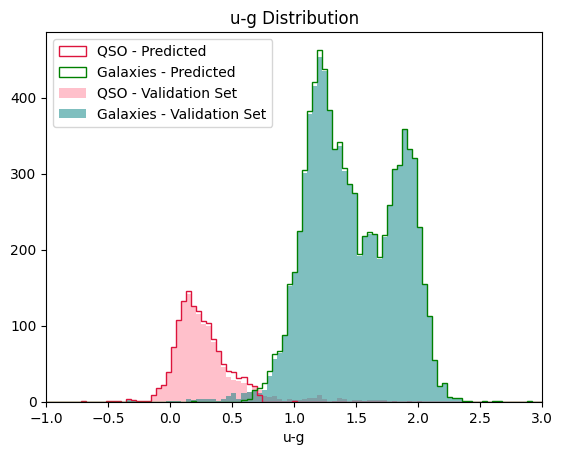

In [34]:
plt.hist(X_test[:,0][y_pred==1],color='crimson',histtype='step',bins=np.linspace(-1,3,100),label='QSO - Predicted')
plt.hist(X_test[:,0][y_pred==0],color='green',histtype='step',bins=np.linspace(-1,3,100),label='Galaxies - Predicted')
plt.xlim(-1,3)
plt.legend();

plt.hist(X_test[:,0][y_test==1],color='pink',bins=np.linspace(-1,3,100), label='QSO - Validation Set');
plt.hist(X_test[:,0][y_test==0],color='teal',alpha=0.5,bins=np.linspace(-1,3,100), label='Galaxies - Validation Set');
plt.title("u-g Distribution")
plt.xlabel('u-g')
plt.legend();

In [20]:
!pip install astroML
from astroML.utils import completeness_contamination
completeness, contamination= completeness_contamination(y_pred,y_test)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 8.7 MB/s eta 0:00:00


In [21]:
def predict_prob(number):
  return [number[0],1-number[0]]

y_prob = np.array(list(map(predict_prob, model.predict(X_valid))))[:,1]
y_prob.shape

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


(5000,)

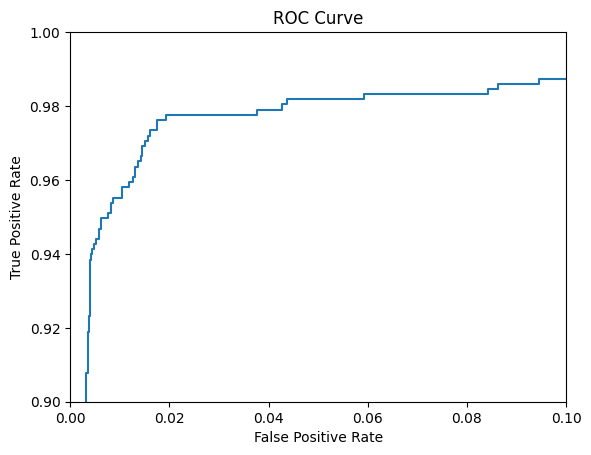

In [22]:
from sklearn.metrics import precision_recall_curve, roc_curve

fpr, tpr, thresh = roc_curve(y_valid, y_prob)
plt.plot(fpr,tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate");

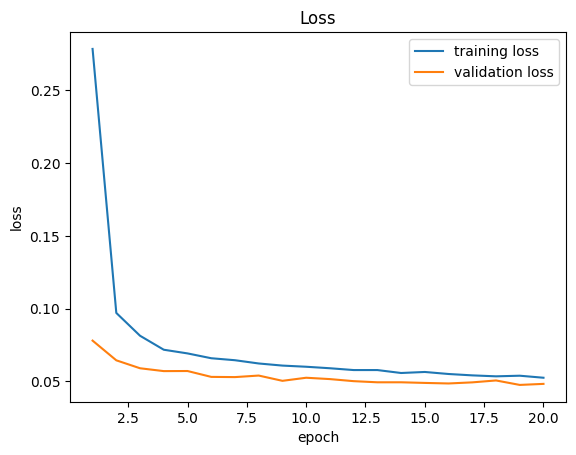

In [23]:
last_epoch = len(clf.history['loss'])
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['loss'], label='training loss')
plt.plot(epochs,clf.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss')
plt.legend();

Max Accuracy:0.9872000217437744


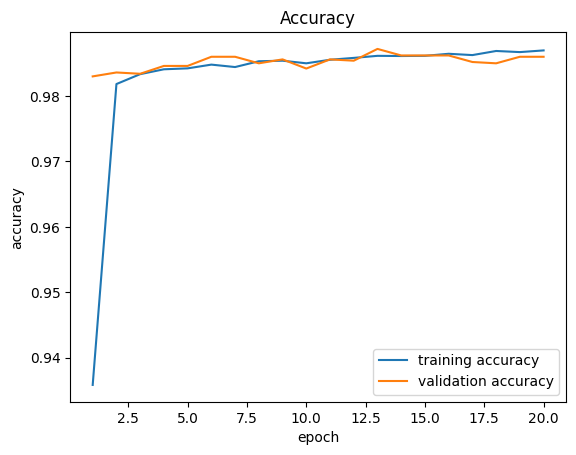

In [24]:
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['accuracy'], label='training accuracy')
plt.plot(epochs,clf.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy')
plt.legend();
print("Max Accuracy:"+str(np.max(clf.history['val_accuracy'])))

Let's see what happens without dimensionality reduction and with an overall easier model!

In [25]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[4, 1]),
    keras.layers.Conv1D(filters=32, kernel_size=7, activation='relu', padding='same'),
    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [26]:
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 4, 32)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,162 (35.79 KB)

 Trainable params: 9,162 (35.79 KB)

 Non-trainable params: 0 (0.00 B)

None


In [27]:
model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.0001), metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7953 - loss: 0.7140 - val_accuracy: 0.8604 - val_loss: 0.2183
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9394 - loss: 0.1767 - val_accuracy: 0.9766 - val_loss: 0.0985
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9737 - loss: 0.1161 - val_accuracy: 0.9790 - val_loss: 0.0882
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9768 - loss: 0.1033 - val_accuracy: 0.9800 - val_loss: 0.0850
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9783 - loss: 0.0952 - val_accuracy: 0.9800 - val_loss: 0.0831
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9790 - loss: 0.0957 - val_accuracy: 0.9804 - val_loss: 0.0809
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9791 - loss: 0.0909 - val_accuracy: 0.9808 - val_loss: 0.0794
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9795 - loss: 0.0907 - 

In [28]:
import sklearn
y_pred=np.argmax(model.predict(X_test), axis=-1)
print(sklearn.metrics.confusion_matrix(y_pred, y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step
[[8493   96]
 [  79 1332]]


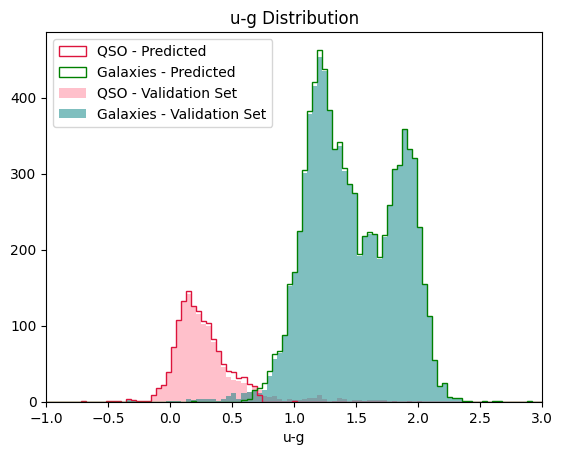

In [35]:
plt.hist(X_test[:,0][y_pred==1],color='crimson',histtype='step',bins=np.linspace(-1,3,100),label='QSO - Predicted')
plt.hist(X_test[:,0][y_pred==0],color='green',histtype='step',bins=np.linspace(-1,3,100),label='Galaxies - Predicted')
plt.xlim(-1,3)
plt.legend();

plt.hist(X_test[:,0][y_test==1],color='pink',bins=np.linspace(-1,3,100), label='QSO - Validation Set');
plt.hist(X_test[:,0][y_test==0],color='teal',alpha=0.5,bins=np.linspace(-1,3,100), label='Galaxies - Validation Set');
plt.title("u-g Distribution")
plt.xlabel('u-g')
plt.legend();

In [29]:
!pip install astroML
from astroML.utils import completeness_contamination
completeness, contamination= completeness_contamination(y_pred,y_test)

In [30]:
def predict_prob(number):
  return [number[0],1-number[0]]

y_prob = np.array(list(map(predict_prob, model.predict(X_valid))))[:,1]
y_prob.shape

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


(5000,)

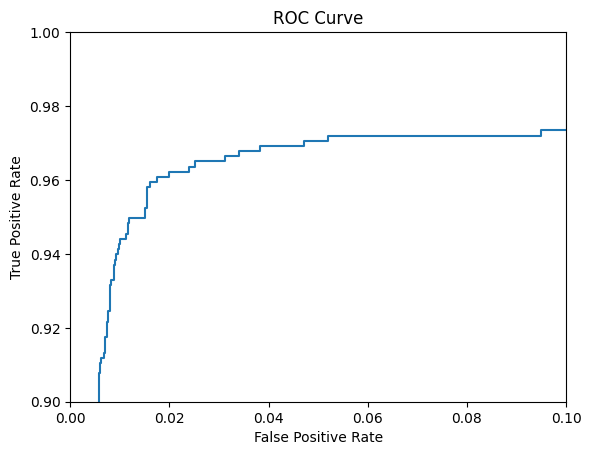

In [31]:
from sklearn.metrics import precision_recall_curve, roc_curve

fpr, tpr, thresh = roc_curve(y_valid, y_prob)
plt.plot(fpr,tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate");

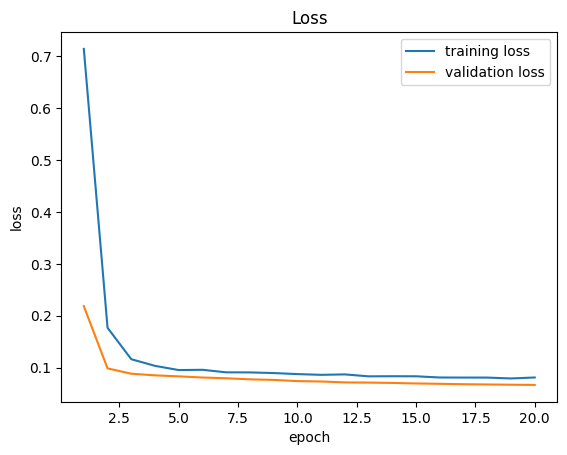

In [32]:
last_epoch = len(clf.history['loss'])
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['loss'], label='training loss')
plt.plot(epochs,clf.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss')
plt.legend();

Max Accuracy:0.9833999872207642


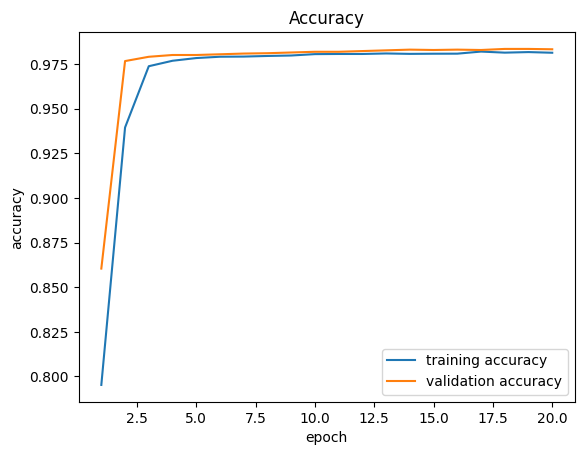

In [33]:
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['accuracy'], label='training accuracy')
plt.plot(epochs,clf.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy')
plt.legend();
print("Max Accuracy:"+str(np.max(clf.history['val_accuracy'])))

Despite an easier model, we arrive at a very high accuracy!

# Learning Rate Cross Validation



In [40]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[4, 1]),
    keras.layers.Conv1D(filters=32, kernel_size=7, activation='relu', padding='same'),
    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

learning_rates=[1e-5,1e-4,1e-3,1e-2,0.1]

for i in range(len(learning_rates)):
  model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=learning_rates[i]), metrics=["accuracy"])
  clf = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

  y_pred=np.argmax(model.predict(X_test), axis=-1)
  print(sklearn.metrics.confusion_matrix(y_pred, y_test))
  print("Max Accuracy:"+str(np.max(clf.history['val_accuracy']))+"with learning rate "+str(learning_rates[i]))

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2656 - loss: 2.1433 - val_accuracy: 0.8552 - val_loss: 1.7799
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8019 - loss: 1.4830 - val_accuracy: 0.8566 - val_loss: 1.0369
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8564 - loss: 0.8758 - val_accuracy: 0.8570 - val_loss: 0.5881
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8572 - loss: 0.5731 - val_accuracy: 0.8570 - val_loss: 0.4304
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8573 - loss: 0.4506 - val_accuracy: 0.8570 - val_loss: 0.3649
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8574 - loss: 0.3850 - val_accuracy: 0.8566 - val_loss: 0.3193
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8593 - loss: 0.3369 - val_accuracy: 0.8564 - val_loss: 0.2786
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8641 - loss: 0.3002 - 

So the learning rate with the highest accuracy is 0.01

In [46]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[4, 1]),
    keras.layers.Conv1D(filters=32, kernel_size=7, activation='relu', padding='same'),
    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.01), metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

y_pred=np.argmax(model.predict(X_test), axis=-1)
print(sklearn.metrics.confusion_matrix(y_pred, y_test))
print("Max Accuracy:"+str(np.max(clf.history['val_accuracy'])))

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9753 - loss: 0.1131 - val_accuracy: 0.9850 - val_loss: 0.0693
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9800 - loss: 0.0856 - val_accuracy: 0.9838 - val_loss: 0.0720
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9809 - loss: 0.0823 - val_accuracy: 0.9844 - val_loss: 0.0705
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9806 - loss: 0.0842 - val_accuracy: 0.9832 - val_loss: 0.0614
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9815 - loss: 0.0769 - val_accuracy: 0.9854 - val_loss: 0.0571
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9809 - loss: 0.0763 - val_accuracy: 0.9848 - val_loss: 0.0576
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9814 - loss: 0.0759 - val_accuracy: 0.9840 - val_loss: 0.0612
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9809 - loss: 0.0781 - val_accurac

In [49]:
def predict_prob(number):
  return [number[0],1-number[0]]

y_prob = np.array(list(map(predict_prob, model.predict(X_valid))))[:,1]
y_prob.shape

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


(5000,)

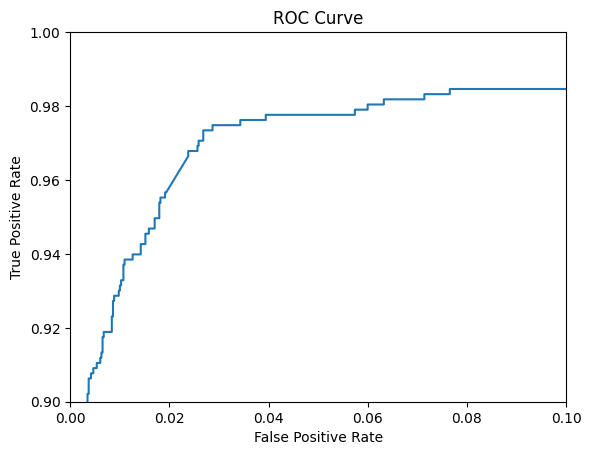

In [50]:
fpr, tpr, thresh = roc_curve(y_valid, y_prob)
plt.plot(fpr,tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate");